# 📦 Olist E-commerce — Análise Exploratória de Dados

**Dataset:** [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)  
**Período:** Set/2016 – Ago/2018  
**Volume:** ~100k pedidos, 9 tabelas relacionais

---
### Perguntas de negócio que vamos responder

1. Qual foi a evolução da receita mensal?
2. Quais categorias mais vendem e mais faturam?
3. Atrasos na entrega afetam a satisfação do cliente?
4. Qual o ticket médio por forma de pagamento?
5. Em quais horários e dias as compras se concentram?
6. Qual o desempenho logístico por estado?


In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.load_data import load_raw, build_master, load_geo

# Tema visual consistente
PALETTE  = ['#2563EB', '#16A34A', '#DC2626', '#D97706', '#7C3AED', '#0891B2']
BLUE     = '#2563EB'
BG       = '#F8FAFC'
plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor':   BG,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.35,
    'grid.color':       '#CBD5E1',
    'font.family':      'sans-serif',
    'font.size':        11,
})

print('✅ Bibliotecas carregadas')

✅ Bibliotecas carregadas


In [2]:
# Carrega e mescla todos os dados
dfs = load_raw()
df  = build_master(dfs)
geo = load_geo(dfs)

print(f'Shape final: {df.shape}')
print(f'Período: {df["order_purchase_timestamp"].min().date()} → {df["order_purchase_timestamp"].max().date()}')
print(f'Pedidos únicos: {df["order_id"].nunique():,.0f}')
print(f'Clientes únicos: {df["customer_unique_id"].nunique():,.0f}')
print(f'Receita total: R$ {df["payment_value"].sum():,.2f}')

Shape final: (110189, 41)
Período: 2016-09-15 → 2018-08-29
Pedidos únicos: 96,470
Clientes únicos: 93,350
Receita total: R$ 19,774,781.52


In [3]:
df.info()

<class 'pandas.DataFrame'>
Index: 110189 entries, 0 to 112649
Data columns (total 41 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       110189 non-null  str           
 1   customer_id                    110189 non-null  str           
 2   order_status                   110189 non-null  str           
 3   order_purchase_timestamp       110189 non-null  datetime64[us]
 4   order_approved_at              110174 non-null  datetime64[us]
 5   order_delivered_carrier_date   110188 non-null  datetime64[us]
 6   order_delivered_customer_date  110189 non-null  datetime64[us]
 7   order_estimated_delivery_date  110189 non-null  datetime64[us]
 8   order_item_id                  110189 non-null  int64         
 9   product_id                     110189 non-null  str           
 10  seller_id                      110189 non-null  str           
 11  shipping_limit_d

In [4]:
df[['payment_value','delivery_days','delay_days','review_score','price','freight_value']].describe().round(2)

,payment_value,delivery_days,delay_days,review_score,price,freight_value
count,110186.00,110189.00,110189.00,109362.00,110189.00,110189.00
mean,179.47,12.01,-11.43,4.08,119.98,19.95
std,271.35,9.45,10.17,1.35,182.30,15.70
min,9.59,0.00,-146.00,1.00,0.85,0.00
25%,65.59,6.00,-17.00,4.00,39.90,13.08
50%,114.34,10.00,-12.00,5.00,74.90,16.26
75%,194.96,15.00,-7.00,5.00,134.17,21.15
max,13664.08,209.00,189.00,5.00,6735.00,409.68


In [7]:
from pathlib import Path
Path('../data/processed').mkdir(parents=True, exist_ok=True)
print('✅ Pasta criada')

✅ Pasta criada


---
## 1. Evolução da Receita Mensal

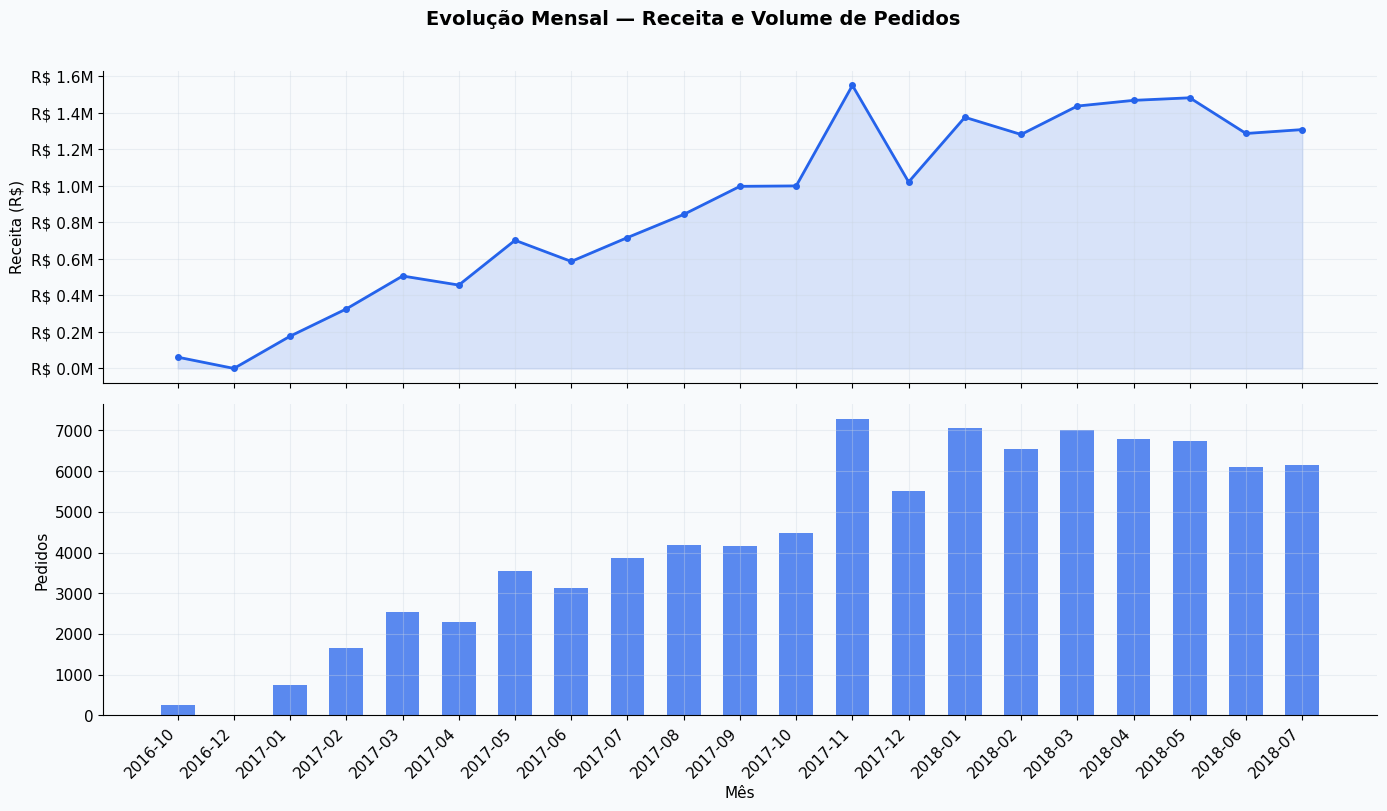

📈 Crescimento: 21.2x no período


In [8]:
monthly = (
    df.groupby('year_month')
    .agg(
        receita=('payment_value', 'sum'),
        pedidos=('order_id', 'nunique'),
    )
    .reset_index()
)
# Remove meses incompletos nas pontas
monthly = monthly.iloc[1:-1]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Evolução Mensal — Receita e Volume de Pedidos', fontsize=14, fontweight='bold', y=1.01)

# Receita
axes[0].fill_between(monthly['year_month'], monthly['receita'], alpha=0.15, color=BLUE)
axes[0].plot(monthly['year_month'], monthly['receita'], color=BLUE, lw=2, marker='o', markersize=4)
axes[0].set_ylabel('Receita (R$)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x/1e6:.1f}M'))

# Volume
axes[1].bar(monthly['year_month'], monthly['pedidos'], color=BLUE, alpha=0.75, width=0.6)
axes[1].set_ylabel('Pedidos')
axes[1].set_xlabel('Mês')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('../data/processed/fig_receita_mensal.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'📈 Crescimento: {monthly["receita"].iloc[-1]/monthly["receita"].iloc[0]:.1f}x no período')

---
## 2. Top Categorias por Receita e Volume

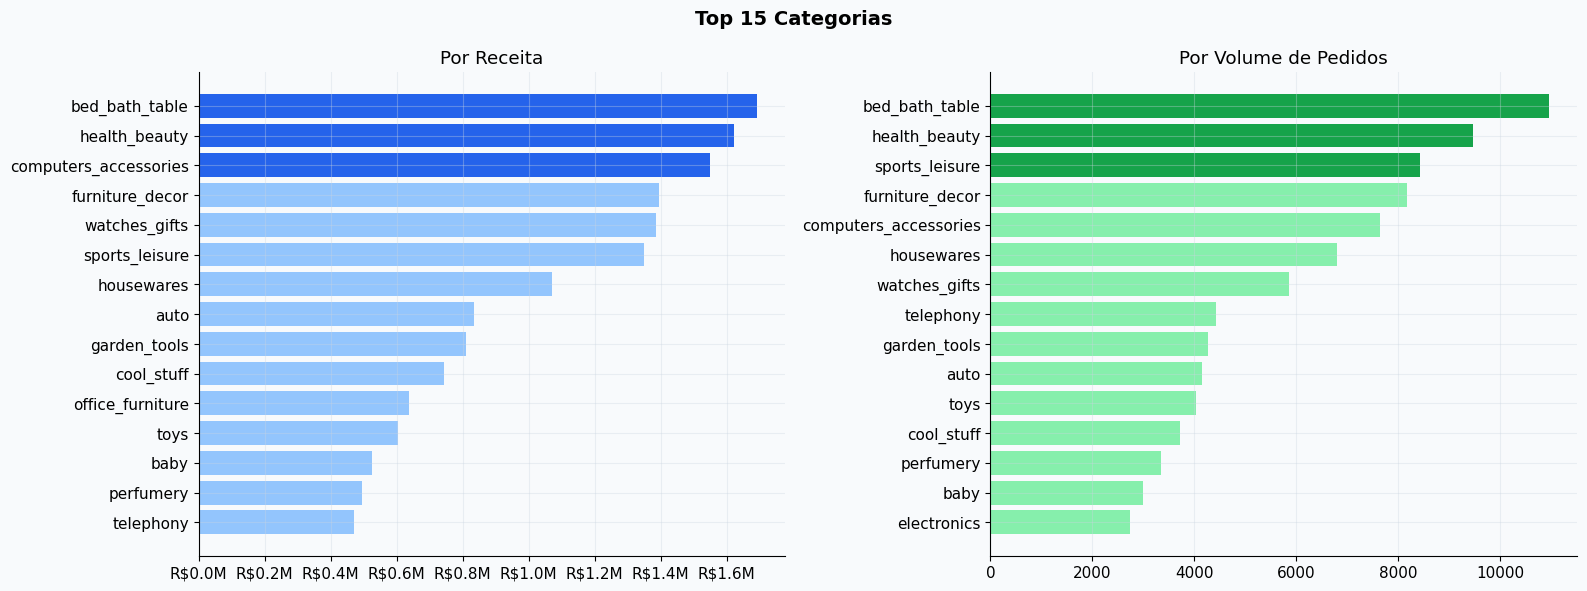

In [9]:
TOP_N = 15

cat = (
    df.groupby('category_en')
    .agg(receita=('payment_value', 'sum'), pedidos=('order_id', 'count'))
    .sort_values('receita', ascending=False)
    .head(TOP_N)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Top {TOP_N} Categorias', fontsize=14, fontweight='bold')

colors_r = [BLUE if i < 3 else '#93C5FD' for i in range(TOP_N)]

# Receita
axes[0].barh(cat.index[::-1], cat['receita'][::-1], color=colors_r[::-1])
axes[0].set_title('Por Receita')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))

# Volume
cat_vol = (
    df.groupby('category_en')
    .agg(pedidos=('order_id', 'count'))
    .sort_values('pedidos', ascending=False)
    .head(TOP_N)
)
colors_v = ['#16A34A' if i < 3 else '#86EFAC' for i in range(TOP_N)]
axes[1].barh(cat_vol.index[::-1], cat_vol['pedidos'][::-1], color=colors_v[::-1])
axes[1].set_title('Por Volume de Pedidos')

plt.tight_layout()
plt.savefig('../data/processed/fig_categorias.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Atrasos na Entrega vs. Satisfação do Cliente

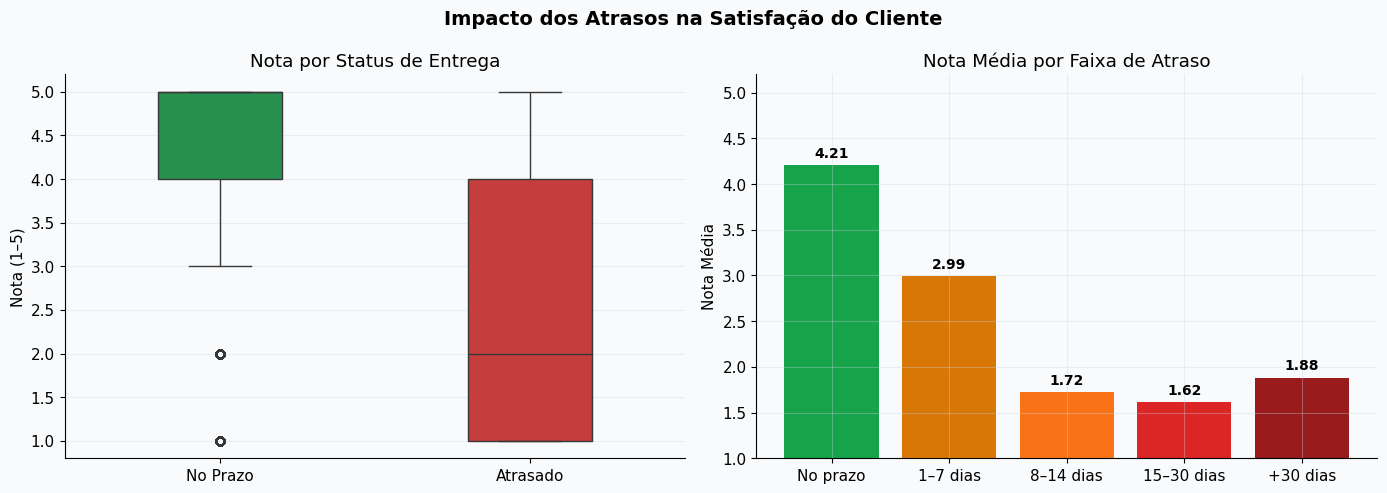

🔗 Correlação dias de atraso × nota: -0.229
📊 % pedidos atrasados: 7.3%


In [10]:
delay_review = df.dropna(subset=['delay_days','review_score']).copy()
delay_review['status_entrega'] = delay_review['is_late'].map({True: 'Atrasado', False: 'No Prazo'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Impacto dos Atrasos na Satisfação do Cliente', fontsize=14, fontweight='bold')

# Boxplot nota por status
sns.boxplot(
    data=delay_review, x='status_entrega', y='review_score',
    palette={'Atrasado': '#DC2626', 'No Prazo': '#16A34A'},
    ax=axes[0], width=0.4
)
axes[0].set_title('Nota por Status de Entrega')
axes[0].set_xlabel('')
axes[0].set_ylabel('Nota (1–5)')

# Nota média por faixa de atraso
bins   = [-99, 0, 7, 14, 30, 99]
labels = ['No prazo', '1–7 dias', '8–14 dias', '15–30 dias', '+30 dias']
delay_review['faixa_atraso'] = pd.cut(delay_review['delay_days'], bins=bins, labels=labels)
avg_score = delay_review.groupby('faixa_atraso', observed=True)['review_score'].mean()

bars = axes[1].bar(avg_score.index, avg_score.values,
                   color=['#16A34A','#D97706','#F97316','#DC2626','#991B1B'])
axes[1].set_title('Nota Média por Faixa de Atraso')
axes[1].set_ylabel('Nota Média')
axes[1].set_ylim(1, 5.2)
for bar, val in zip(bars, avg_score.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.05, f'{val:.2f}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/fig_atrasos_satisfacao.png', dpi=150, bbox_inches='tight')
plt.show()

corr = delay_review[['delay_days','review_score']].corr().iloc[0,1]
print(f'🔗 Correlação dias de atraso × nota: {corr:.3f}')
print(f'📊 % pedidos atrasados: {delay_review["is_late"].mean()*100:.1f}%')

---
## 4. Ticket Médio por Forma de Pagamento

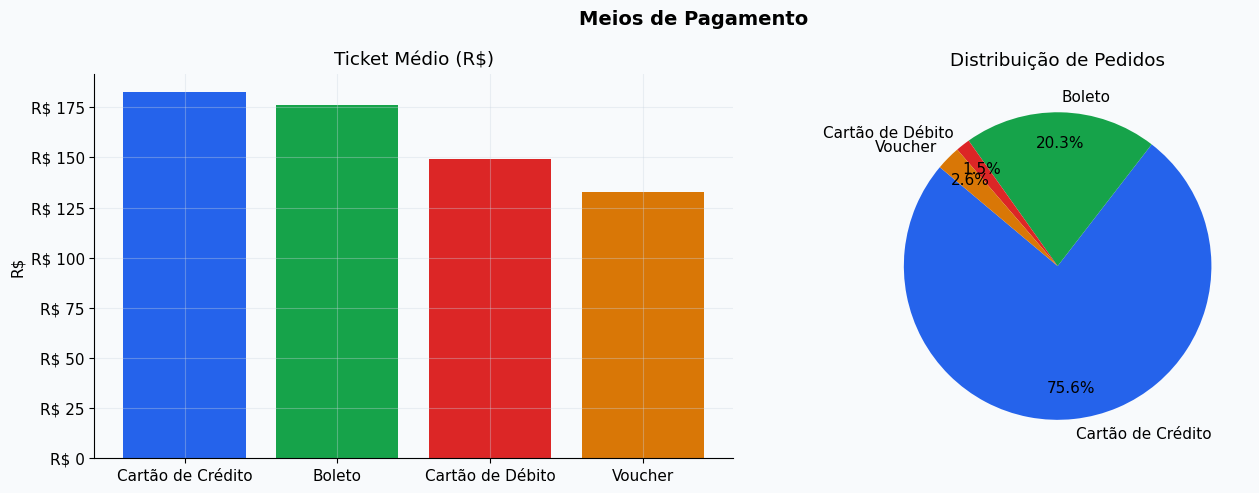

In [11]:
pay_labels = {
    'credit_card': 'Cartão de Crédito',
    'boleto':      'Boleto',
    'voucher':     'Voucher',
    'debit_card':  'Cartão de Débito',
}

pay_stats = (
    df.groupby('payment_type')
    .agg(
        ticket_medio=('payment_value', 'mean'),
        total=('payment_value', 'sum'),
        pedidos=('order_id', 'count'),
    )
    .reset_index()
)
pay_stats['payment_type'] = pay_stats['payment_type'].map(pay_labels).fillna(pay_stats['payment_type'])
pay_stats = pay_stats.sort_values('ticket_medio', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Meios de Pagamento', fontsize=14, fontweight='bold')

axes[0].bar(pay_stats['payment_type'], pay_stats['ticket_medio'],
            color=PALETTE[:len(pay_stats)])
axes[0].set_title('Ticket Médio (R$)')
axes[0].set_ylabel('R$')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:.0f}'))

axes[1].pie(pay_stats['pedidos'], labels=pay_stats['payment_type'],
            autopct='%1.1f%%', colors=PALETTE[:len(pay_stats)],
            startangle=140, pctdistance=0.8)
axes[1].set_title('Distribuição de Pedidos')

plt.tight_layout()
plt.savefig('../data/processed/fig_pagamentos.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Horário e Dia da Semana das Compras

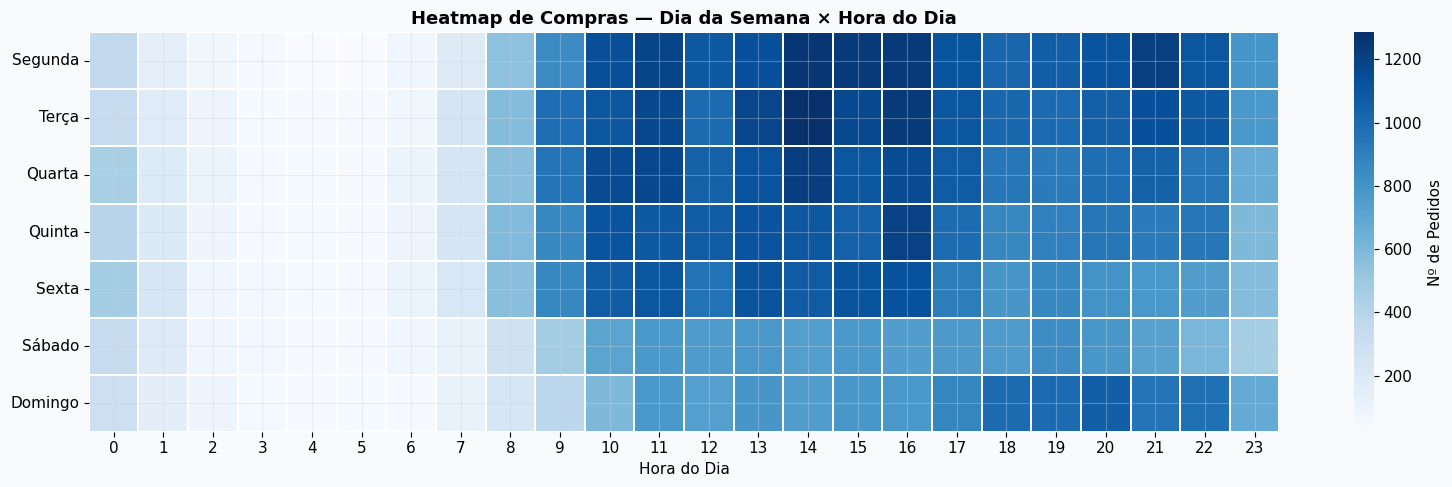

In [12]:
DOW_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
DOW_PT    = ['Segunda','Terça','Quarta','Quinta','Sexta','Sábado','Domingo']

pivot = (
    df.groupby(['day_of_week', 'hour'])['order_id']
    .count()
    .reset_index()
    .pivot(index='day_of_week', columns='hour', values='order_id')
    .reindex(DOW_ORDER)
)
pivot.index = DOW_PT

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    pivot, cmap='Blues', ax=ax, linewidths=0.3,
    cbar_kws={'label': 'Nº de Pedidos'}, fmt='.0f'
)
ax.set_title('Heatmap de Compras — Dia da Semana × Hora do Dia', fontsize=13, fontweight='bold')
ax.set_xlabel('Hora do Dia')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig('../data/processed/fig_heatmap_tempo.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Desempenho Logístico por Estado

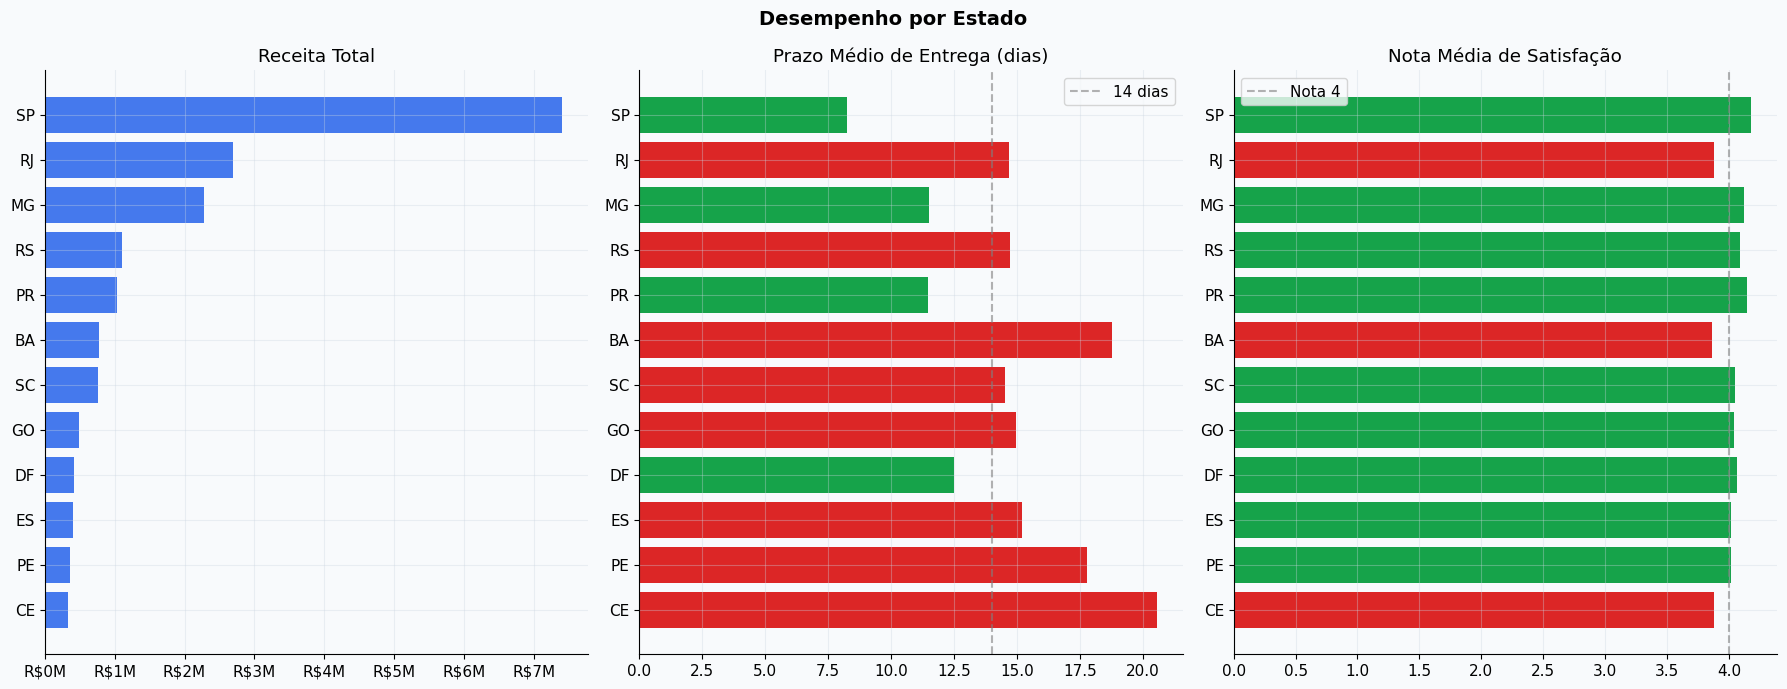


📊 Top 10 Estados por Receita:
customer_state  pedidos    receita  ticket_medio  prazo_medio  nota_media  pct_atraso
            SP    46441 7402808.37    159.412730     8.259663    4.180138         5.2
            RJ    14143 2688933.90    190.124719    14.688821    3.877094        12.4
            MG    12916 2281229.16    176.620406    11.514091    4.123733         5.0
            RS     6133 1110782.47    181.115681    14.708299    4.094046         6.4
            PR     5649 1030822.39    182.478738    11.480793    4.149360         4.4
            BA     3683  773182.02    209.932669    18.774640    3.863798        12.9
            SC     4097  767093.97    187.233090    14.517208    4.047994         9.1
            GO     2277  493068.70    216.543127    14.948177    4.045049         7.2
            DF     2355  421374.86    178.927754    12.501486    4.066296         6.9
            ES     2225  398321.90    179.021079    15.192809    4.016408        11.8


In [13]:
estado = (
    df.groupby('customer_state')
    .agg(
        pedidos=('order_id', 'count'),
        receita=('payment_value', 'sum'),
        ticket_medio=('payment_value', 'mean'),
        prazo_medio=('delivery_days', 'mean'),
        nota_media=('review_score', 'mean'),
        pct_atraso=('is_late', 'mean'),
    )
    .reset_index()
    .sort_values('receita', ascending=False)
)
estado['pct_atraso'] = (estado['pct_atraso'] * 100).round(1)

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('Desempenho por Estado', fontsize=14, fontweight='bold')

top12 = estado.head(12)

axes[0].barh(top12['customer_state'][::-1], top12['receita'][::-1], color=BLUE, alpha=0.85)
axes[0].set_title('Receita Total')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.0f}M'))

color_prazo = ['#DC2626' if v > 14 else '#16A34A' for v in top12['prazo_medio'][::-1]]
axes[1].barh(top12['customer_state'][::-1], top12['prazo_medio'][::-1], color=color_prazo)
axes[1].axvline(14, color='gray', linestyle='--', alpha=0.6, label='14 dias')
axes[1].set_title('Prazo Médio de Entrega (dias)')
axes[1].legend()

color_nota = ['#16A34A' if v >= 4 else '#DC2626' for v in top12['nota_media'][::-1]]
axes[2].barh(top12['customer_state'][::-1], top12['nota_media'][::-1], color=color_nota)
axes[2].axvline(4.0, color='gray', linestyle='--', alpha=0.6, label='Nota 4')
axes[2].set_title('Nota Média de Satisfação')
axes[2].legend()

plt.tight_layout()
plt.savefig('../data/processed/fig_estados.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Top 10 Estados por Receita:')
print(estado[['customer_state','pedidos','receita','ticket_medio','prazo_medio','nota_media','pct_atraso']]
      .head(10).to_string(index=False))

---
## 7. Exportar dados tratados para Power BI

In [14]:
from pathlib import Path
PROC = Path('../data/processed')

# Master
cols_export = [
    'order_id','customer_unique_id','customer_state','customer_city',
    'order_purchase_timestamp','year','month','year_month','hour','day_of_week',
    'category_en','payment_type','payment_value','price','freight_value',
    'delivery_days','delay_days','is_late','review_score','installments',
]
df[cols_export].to_csv(PROC / 'olist_master.csv', index=False)

# Tabelas resumo
monthly.to_csv(PROC / 'olist_mensal.csv', index=False)
estado.to_csv(PROC  / 'olist_estados.csv', index=False)

print('✅ Arquivos exportados para data/processed/')
for f in sorted(PROC.glob('*.csv')):
    print(f'   {f.name}')

✅ Arquivos exportados para data/processed/
   olist_estados.csv
   olist_master.csv
   olist_mensal.csv


In [16]:
df[cols_export].to_csv(PROC / 'olist_master.csv', index=False, decimal=',', sep=';')
monthly.to_csv(PROC / 'olist_mensal.csv', index=False, decimal=',', sep=';')
estado.to_csv(PROC / 'olist_estados.csv', index=False, decimal=',', sep=';')
print('✅ CSVs exportados com separador ponto e vírgula')

✅ CSVs exportados com separador ponto e vírgula


In [17]:
# Verificar valores reais
print("payment_value médio:", df['payment_value'].mean().round(2))
print("payment_value max:", df['payment_value'].max())
print("Exemplo:", df['payment_value'].head(3).values)

payment_value médio: 179.47
payment_value max: 13664.08
Exemplo: [ 38.71 141.46 179.12]
